# Fund Workstation

### Setting Up the Environment

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT LS','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['MSCI CHINA','TOPIX','S&P 500','MSCI WORLD', 'EUREKAHEDGE']

#### Load Data via .json

In [2]:
test = load_saved_json(folder_path=r"input")
print(type(test))
Funds = init_funds(test)
print(Funds)

<class 'list'>
{'CRABEL MULTI': Fund(performance_fee=0.3, management_fee=0.02, monthly_returns=328 entries), '3W CHINA': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=161 entries), 'EUREKAHEDGE': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=91 entries), 'FOREST': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=63 entries), 'JH BIOTECH': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=67 entries), '3W HEALTHCARE': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=54 entries), 'LIM': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=79 entries), 'S&P 500': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=104 entries), '3W GLOBAL': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=126 entries), 'HAO': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=132 entries), 'MSCI WORLD': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=218 entries), 'TIMEF

#### Load Data via .csv

In [3]:
funds = input_monthly_returns(r"RETURN DATA.csv")



#### GPT Input Factsheet

In [4]:
k = process_pdfs_in_folder(save=True)

Processing: input/Crabel.pdf


KeyboardInterrupt: 

#### Process Input

In [4]:
merged = Funds|funds

#### Save the Changes

In [7]:
save_changes_in_fund(merged)

✅ No existing CSV found. Created new CSV at input/returns.csv


### Compare Multiple Funds

In [6]:
df = compare_funds(merged)
df

,Name,Description,Location,Strategy,Sector,Managers,Contact,AUM,Net Exposure,Net Return,...,Inception Date,Latest Date,# Months,Cumulative Return,Annualized Return,Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Positive Months
0,CRABEL MULTI,CRABEL MULTI-PRODUCT 1X is a global systematic...,[global],"[systematic, futures_short_term]",NaN,"Michael Pomada, Toby Crabel, Steve Wisdom, Gra...","Lisa Martin - Based in Los Angeles, United Sta...",1576.0,[0.08],True,...,1998-03-01,2025-06-01,328,6.480199,0.076397,0.123727,0.617464,1.342092,0.162644,0.609756
1,3W CHINA,None,None,None,None,None,No contact info,NaN,None,None,...,2012-03-01,2025-07-01,161,3.993634,0.127343,0.074912,1.699901,3.642958,0.096000,0.689441
2,EUREKAHEDGE,None,None,None,None,None,No contact info,NaN,None,None,...,2018-01-01,2025-07-01,91,0.448562,0.050080,0.074657,0.670802,1.118665,0.138768,0.582418
3,FOREST,None,None,None,None,None,No contact info,NaN,None,None,...,2020-05-01,2025-07-01,63,1.348594,0.176603,0.089504,1.973128,3.927223,0.088300,0.809524
4,JH BIOTECH,None,None,None,None,None,No contact info,NaN,None,None,...,2020-01-01,2025-07-01,67,4.856673,0.372429,0.236598,1.574098,3.612567,0.223271,0.686567
5,3W HEALTHCARE,None,None,None,None,None,No contact info,NaN,None,None,...,2021-02-01,2025-07-01,54,0.036359,0.007968,0.206635,0.038561,0.052192,0.544285,0.592593
6,LIM,None,None,None,None,None,No contact info,NaN,None,None,...,2019-01-01,2025-07-01,79,1.839720,0.171796,0.069608,2.468054,6.010626,0.087128,0.772152
7,S&P 500,None,None,None,None,None,No contact info,NaN,None,None,...,2016-12-01,2025-07-01,104,2.338674,0.149244,0.158604,0.940989,1.495105,0.238714,0.701923
8,3W GLOBAL,None,None,None,None,None,No contact info,NaN,None,None,...,2015-02-01,2025-07-01,126,6.133250,0.205773,0.131850,1.560659,4.566397,0.106092,0.690476
9,HAO,None,None,None,None,None,No contact info,NaN,None,None,...,2014-08-01,2025-07-01,132,25.713837,0.348042,0.265242,1.312165,2.889132,0.211048,0.636364


In [22]:
# Combine all conditions in a single filter
filtered = df[
    (df["Sharpe Ratio"] > 1) &
    (df["Annualized Return"] > 0.1) 
]

# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", 
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]

# Then, select only the columns you want
filtered = filtered[["Name", "Location", "Strategy", "AUM", "Sharpe Ratio", "Annualized Return"]]
filtered


,Name,Location,Strategy,AUM,Sharpe Ratio,Annualized Return
1,3W CHINA,None,None,NaN,1.699901,0.127343
3,FOREST,None,None,NaN,1.973128,0.176603
4,JH BIOTECH,None,None,NaN,1.574098,0.372429
6,LIM,None,None,NaN,2.468054,0.171796
8,3W GLOBAL,None,None,NaN,1.560659,0.205773
9,HAO,None,None,NaN,1.312165,0.348042
12,WT LS,None,None,NaN,1.751601,0.206003
14,PERSEVERANCE,None,None,NaN,1.170069,0.242088
15,MONOLITH,None,None,NaN,1.284283,0.226825
16,E20,None,None,NaN,11.477959,2.111447


In [ ]:
filtered.to_csv("output/funds_comparison.csv", index=False)

### Plot Cumulative Retrun Graphs

In [ ]:

funds_to_be_plot = subset_of_funds(merged, ['CRABEL MULTI', 'MSCI WORLD'])
start_month = "2007-12"
end_month = "2025-7"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False
    )


### Correlation Heat Map

In [ ]:
# Correlation heatmap

funds_to_be_plot = funds
start_month = "2019-12"
end_month = "2020-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

### Summary of a Fund

CRABEL MULTI-PRODUCT 1X is a global systematic hedge fund specializing in short-term futures and FX trading. It employs a diversified portfolio of short-term momentum and mean reversion strategies with a one-day holding period focus. The fund targets low correlation with traditional markets and manages risk dynamically to achieve an 8% annualized volatility. Managed by experienced professionals including founder Toby Crabel and CEO Michael Pomada. Rating: 4, overall positive view due to strong systematic approach and risk management.
Net Exposure = 8.0% to 8.0%
Lisa Martin - Based in Los Angeles, United States, try reachout via email '' or phone ''
{'Michael Pomada': {'summary': 'President and CEO of CCM, portfolio manager focusing on research, product development, and front office oversight.', 'location': 'Los Angeles, United States', 'years_of_experience': 16}, 'Toby Crabel': {'summary': 'Founder, Chairman, and CIO of CCM, leads research and management, pioneer in short-term price pa

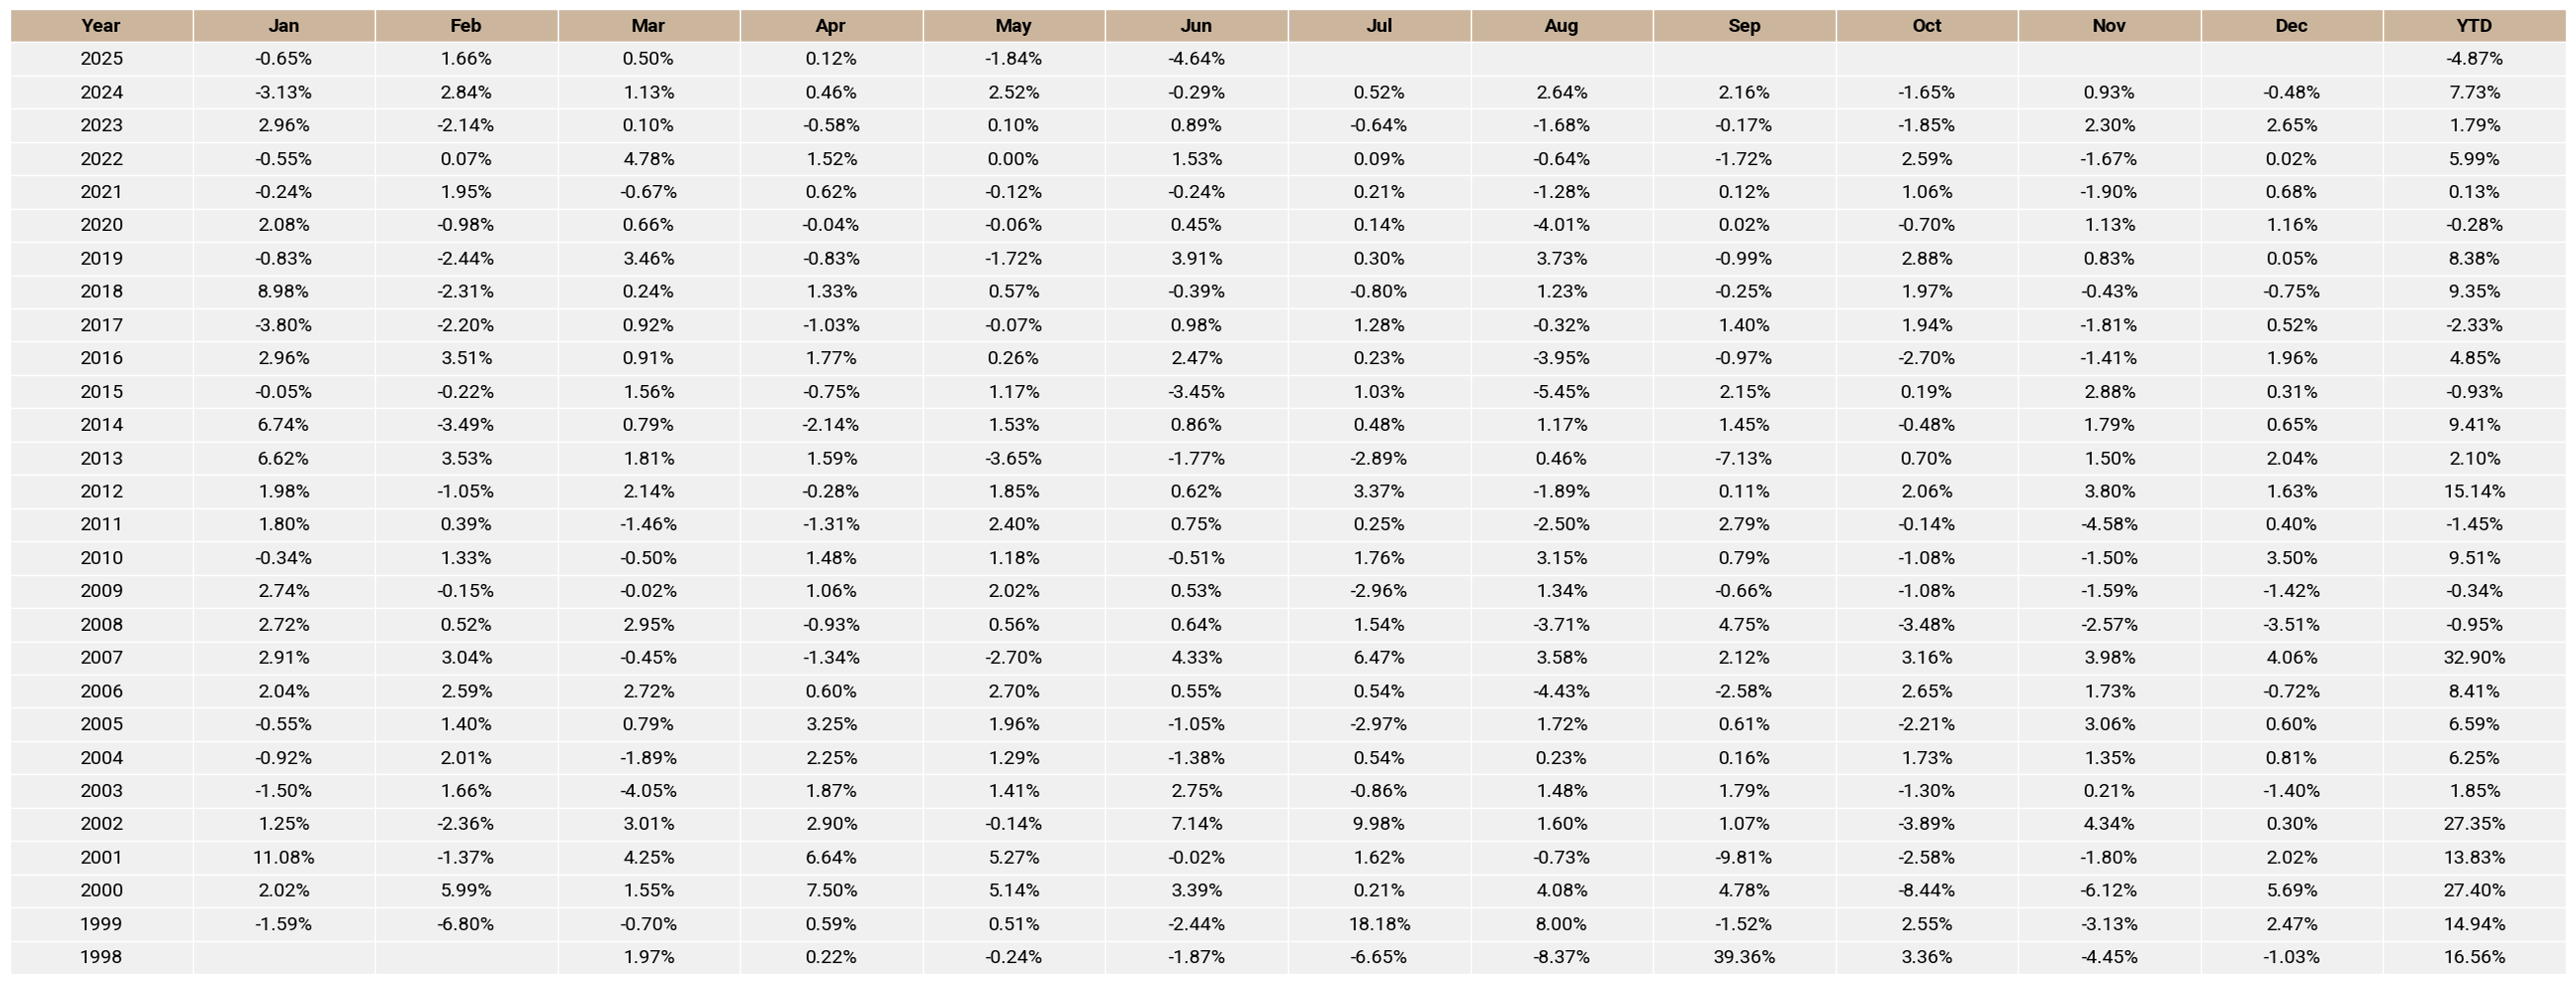

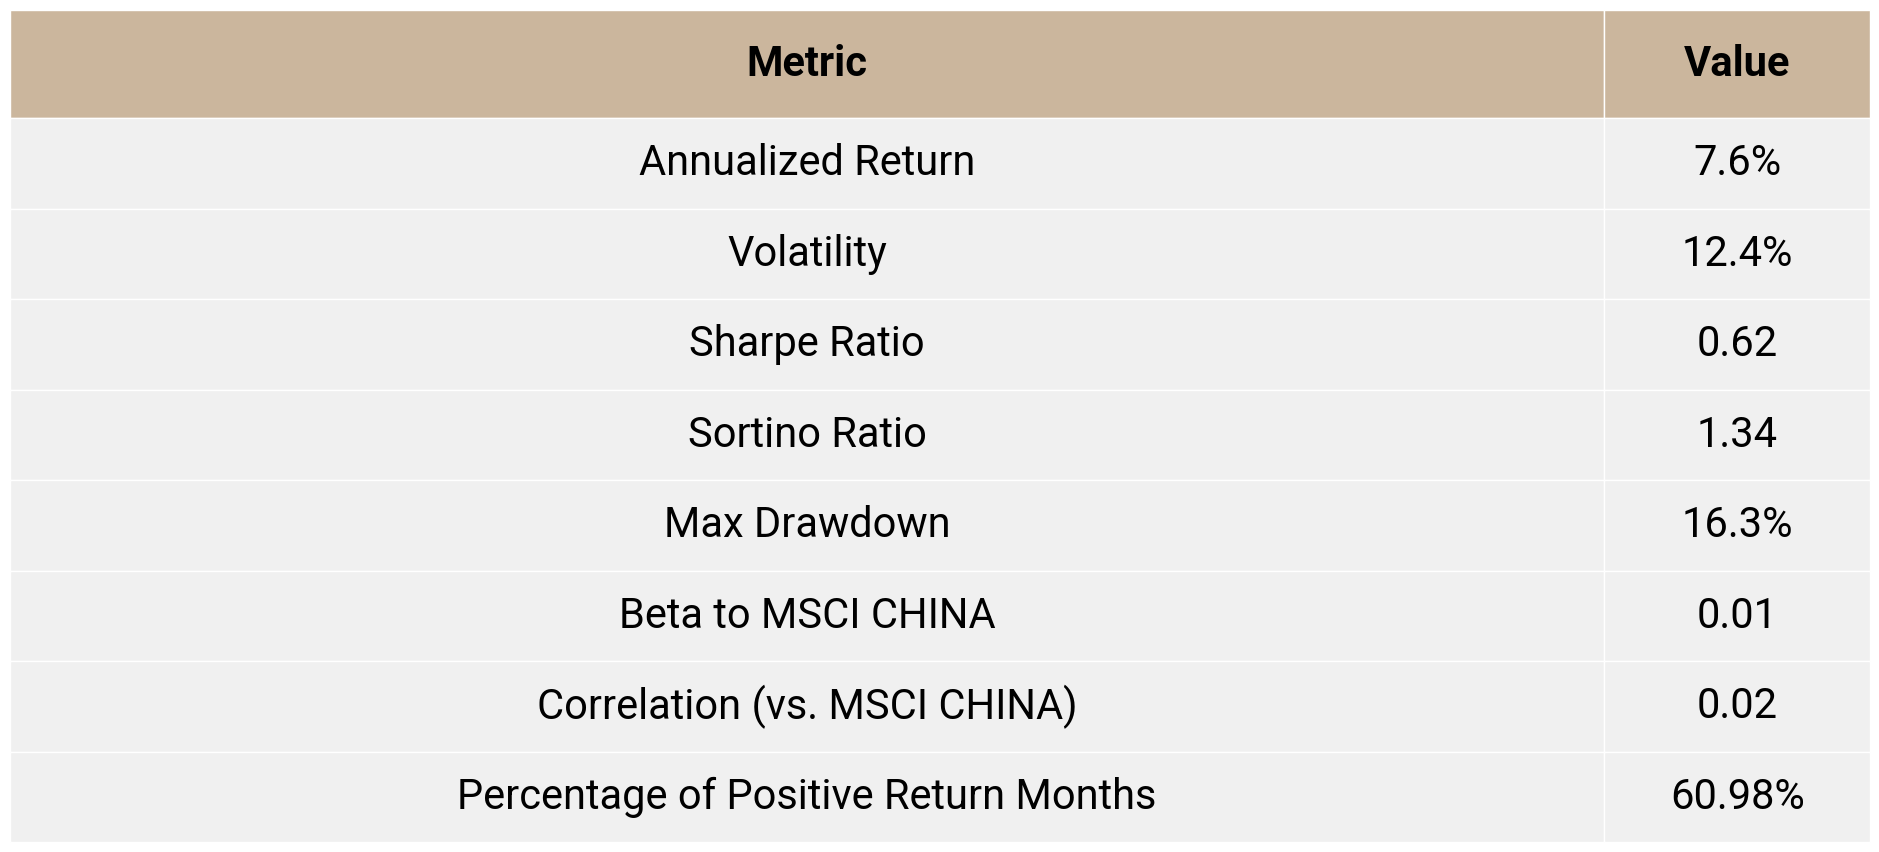

(None,
 None,
 Figure({
     'data': [{'histnorm': 'percent',
               'hovertemplate': '<b>%{x.start:.2%} – %{x.end:.2%}</b><br>%{y:.1f}% of months<extra></extra>',
               'marker': {'color': 'rgba(193,174,148,0.55)', 'line': {'color': 'rgba(193,174,148,0.85)', 'width': 0.8}},
               'name': 'CRABEL MULTI',
               'nbinsx': 24,
               'opacity': 0.95,
               'showlegend': False,
               'type': 'histogram',
               'x': {'bdata': ('sb/snjwslD8vbqMBvAViP2EyVTAqqW' ... 'UwKqlTP0hQ/Bhz15K/4JwRpb3Bp78='),
                     'dtype': 'f8'}},
              {'hovertemplate': '<b>%{x:.2%}</b><br>%{y:.2f}% (smooth)<extra></extra>',
               'line': {'color': '#C1AE94', 'width': 3},
               'mode': 'lines',
               'name': 'KDE',
               'showlegend': False,
               'type': 'scatter',
               'x': {'bdata': ('7OI2GsBbvr+AHzsZQgS+vxVcPxjErL' ... '3bqVTaP5e7TFuJato/cayL22iA2j8='),
              

In [6]:
merged['CRABEL MULTI'].summary_of_a_fund(funds['MSCI CHINA'],language="en")

#### Quick Investigation

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]

fig = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )